# Dia 1: Projeto NPS


In [25]:

# @title
# TODO: Evoluir a implementação para separar melhor as responsabilidades (funcional)
#LÓGICA DO CONTADOR NPS

#import pandas as pd

#def calcular_nps(notas):
  #detratores = 0
  #promotores = 0

  #for nota in notas:

    #if nota >= 9:
      #promotores += 1

    #elif nota <= 6:
      #detratores += 1
    # 7 e 8 ficam na zona Neutra do nps
    # Detratores de 0 a 6
    # Promotores de 9 a 10

  #nps = (promotores - detratores) / len(notas) * 100
  #return nps


#dados = pd.read_csv('/content/feedbacks.csv', delimiter=';')
#notas = dados['nota']
#Os arquivos na planilha estão separados por ';' geralmente o programa
#espera estar separados por ','

#print(calcular_nps(notas))

**O NPS (Net Promoter Score)** é uma métrica de satisfação do cliente que mede a probabilidade de um cliente recomendar um produto ou serviço a outras pessoas. Ele é calculado com base em uma pergunta simples: "Em uma escala de 0 a 10, qual a probabilidade de você recomendar nossa empresa/produto/serviço a um amigo ou colega?".

In [26]:
#TODO: Baixar o arquivo CSV do Google Drive e carregar seus dados em um DataFrame pandas.

#Este código baixa um arquivo CSV de feedbacks do Google Drive e carrega os dados em um DataFrame pandas.
#O arquivo é identificado por um ID único ('file_id'), que é extraído da URL do arquivo no Google Drive.
#A URL do arquivo no Google Drive tem o seguinte formato:
#https://drive.google.com/file/d/FILE_ID/view?usp=sharing

import gdown
import pandas as pd

file_id = '1wSCf_zV3wl4A3V5U5fgL7kQV1CqtbUqP'
gdown.download(f'https://drive.google.com/uc?id={file_id}','feedbacks-dev-week.csv')
#Fez o download do arquivo


Downloading...
From: https://drive.google.com/uc?id=1wSCf_zV3wl4A3V5U5fgL7kQV1CqtbUqP
To: /content/feedbacks-dev-week.csv
100%|██████████| 404/404 [00:00<00:00, 1.28MB/s]


'feedbacks-dev-week.csv'

In [27]:
#Ler o arquivo CSV baixado em um DataFrame pandas e exibi-lo no display
import pandas as pd

try:
    feedbacks_df = pd.read_csv('/content/feedbacks-dev-week.csv', delimiter=';')
    #Os arquivos na planilha estão separados por ';' geralmente o programa espera estar separados por ','
    display(feedbacks_df)
except FileNotFoundError:
    print("Error: feedbacks.csv not found. Please ensure the download was successful.")

,nota,comentario
0,10,"Excelente Bootcamp, estou muito satisfeita!"
1,9,"Bootcamp top, mas mentorias de IA o tornariam ..."
2,6,"Um Bootcamp razoável, torcendo para o próximo ..."
3,10,"Bootcamp incrível, continue potencializando a ..."
4,7,"O Bootcamp foi ok, nada de especial."
5,9,Show de Bola
6,10,Bom Demais
7,8,"Amei, Bootcamp incrivel"
8,0,Bootcamp horrivel
9,4,Curso desatualizada



**Versão Usada para o Projeto: Paradigma Orientado a Objetos (POO).**

Este script adota uma abordagem Orientada a Objetos (POO) para calcular o NPS a partir de feedback de usuários.
Duas classes são definidas, onde:
- Feedback representa um único feedback de usuário;
- AnalisadorFeedback é usado para calcular o NPS a partir de uma lista de Feedbacks.
A POO fornece uma abstração mais clara dos dados e comportamentos envolvidos no cálculo do NPS.
Desta forma, nossa solução estará preparada para as evoluções do nosso projeto.


In [28]:
#TODO: Abstrair o problema usando classes e objetos (orientação a objetos)
import pandas as pd

class Feedback:
  #Atributos (obj,  ..., ...)
  def __init__(self, nota, comentario):
    self.nota = nota
    self.comentario = comentario

class AnalisadorFeedbacks:
  def __init__(self, feedbacks):
    self.feedbacks = feedbacks

  def calcular_nps(self):
      detratores = sum([1 for feedback in self.feedbacks if feedback.nota <= 6])
      promotores = sum([1 for feedback in self.feedbacks if feedback.nota >= 9])

      return (promotores - detratores) / len(self.feedbacks) * 100

dados = pd.read_csv('/content/feedbacks-dev-week.csv', delimiter=';')

#Mostra os dados por linhas:
#Mostra usando a classe
feedbacks = [Feedback(linha['nota'],linha['comentario']) for indice, linha in dados.iterrows()]
#Mostra usando a biblioteca Pandas
"feedbacks = dados.aply(lambda linha: Feedback(linha['nota'],linha['comentario']), axis=1)"

analisador = AnalisadorFeedbacks(feedbacks)
nps = analisador.calcular_nps()
print(nps)


20.0


# Dia 2: O poder de Dados com Python

Conectando nosso Google Colab ao Google Drive,para extrair dados do NPS e aplicar as técnicas de ETL (Extração, Transformação e Carregamento) nesses dados. Com a ajuda da biblioteca matplotlib, criaremos gráficos para visualizar e compreender o nível de satisfação dos nossos usuários.


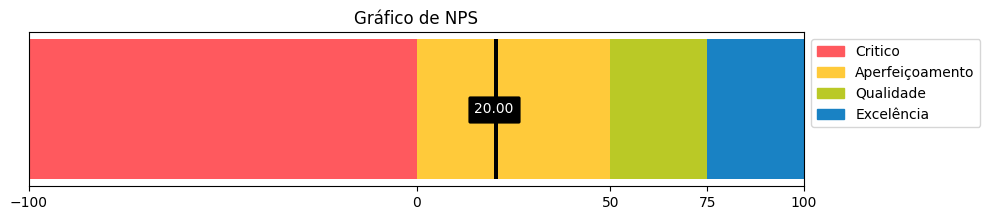

In [29]:
#TODO: Criar um gráfico usando "matplotlib" para visualizar o NPS que calculamos no Dia 1!
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

#Definições das constantes que usaremos para visualizar o NPS
NPS_ZONAS = ['Critico','Aperfeiçoamento','Qualidade','Excelência']
NPS_VALORES = [-100,0,50,75,100]
NPS_CORES = ['#FF595E','#FFCA3A','#BAC926','#1982C4']


def criar_grafico_nps(nps):
  #Criação da Figuração
  fig, ax = plt.subplots(figsize=(10,2)) #(largura,altura)

  for i, zona in enumerate(NPS_ZONAS):
    ax.barh([0], width=NPS_VALORES[i+1]-NPS_VALORES[i], left=NPS_VALORES[i], color=NPS_CORES[i])
    #Criando uma barra Horizontal,
    #calculo do espaço que ela vai ocupar no grafico com base na diferença dos valores de "NPS_VALORES",
    #left vai passar o valor especifico da barra do valor que está começando para mostrar
    #E color irá passar a cor

     # Cria a "seta" que vai indicar o NPS no gráfico.
    ax.barh([0], width=1, left=nps, color='black')
    ax.set_yticks([]) # Remove os ticks do eixo Y
    ax.set_xlim(-100,100) # Define os limites do eixo X
    ax.set_xticks(NPS_VALORES)  # Define os ticks do eixo X

    # Inclui um texto com o valor de NPS, o qual ficará alinhado com a "seta" criada anteriormente.
    plt.text(nps,0,f'{nps:.2f}', ha='center', va='center', color='white', bbox=dict(facecolor='black'))


    patches = [mpatches.Patch(color=NPS_CORES[i],label=NPS_ZONAS[i]) for i in range(len(NPS_ZONAS))] # Cria a legenda do gráfico
    plt.legend(handles=patches, bbox_to_anchor=(1,1)) #Posição da Tabela

    plt.title('Gráfico de NPS')

  plt.show() #Exibir Grafico
criar_grafico_nps(nps)


#Dia 3: Decifrando Sentimentos com Inteligência Artificial (IA)

Vamos utilizar as técnicas de Processamento de Linguagem Natural (PLN) para analisar os sentimentos expressos nos comentários associados às notas de NPS. Dessa forma, teremos uma perspectiva qualitativa que complementa nossos dados quantitativos.

In [30]:
# Para gerar uma API Key da OpenAI:
# 1. Crie uma conta na OpenAI
# 2. Acesse a seção "API Keys"
# 3. Clique em "Create API Key"
# Link direto: https://platform.openai.com/account/api-keys

# Para usar a chave de API da OpenAI de forma segura no Colab,
# adicione-a aos "Secrets" (ícone de chave 🔑 na barra lateral esquerda)
# com o nome 'OPENAI_API_KEY'.

# TODO: Configurar a chave de API da OpenAI.

# Importe a biblioteca para acessar secrets do Colab
from google.colab import userdata

# Acesse a chave de API da OpenAI dos Secrets do Colab
try:
    openai_api_key = userdata.get('OPENAI_API_KEY')
    print("API key da OpenAI configurada com sucesso.")
except userdata.SecretNotFoundError:
    print("Erro: OPENAI_API_KEY não encontrada nos Secrets do Colab.")


API key da OpenAI configurada com sucesso.


In [31]:
#Integrar com o ChatGPT e usá-lo como um modelo para análise de sentimentos dos nossos comentários.
#1. Endpoint consumida: https://platform.openai.com/docs/api-reference/chat/create

# Importe a biblioteca OpenAI
import openai
import pandas as pd

# Para gerar uma API Key da OpenAI:
# 1. Crie uma conta na OpenAI
# 2. Acesse a seção "API Keys"
# 3. Clique em "Create API Key"
# Link direto: https://platform.openai.com/account/api-keys

# Para usar a chave de API da OpenAI de forma segura no Colab,
# adicione-a aos "Secrets" (ícone de chave 🔑 na barra lateral esquerda)
# com o nome 'OPENAI_API_KEY'.

# TODO: Configurar a chave de API da OpenAI.

# Importe a biblioteca para acessar secrets do Colab
from google.colab import userdata

# Acesse a chave de API da OpenAI dos Secrets do Colab
try:
    openai_api_key = userdata.get('OPENAI_API_KEY')
    print("API key da OpenAI configurada com sucesso a partir dos Secrets.")
except userdata.SecretNotFoundError:
    print("Erro: OPENAI_API_KEY não encontrada nos Secrets do Colab.")


# Nova abordagem baseada em cliente da OpenAI
try:
    # Inicialização do Cliente da Open AI
    client = openai.OpenAI(api_key=openai_api_key)
    print("Cliente OpenAI inicializado.")
except NameError:
     print("Erro: A variável 'openai_api_key' não foi encontrada.")
except Exception as e:
     print(f"Erro ao inicializar o cliente OpenAI: {e}")
     client = None


def analisar_sentimentos(feedbacks):
  if client is None:
      return "Análise de sentimento não disponível."

  # Formatando os comentários para enviar ao modelo
  comentarios_validos = [f.comentario for f in feedbacks if hasattr(f, 'comentario') and f.comentario is not None and pd.notna(f.comentario)]

  # Verifica se há comentários válidos para analisar
  if not comentarios_validos:
      return "Não há comentários válidos para analisar."

  # Junta todos os comentários válidos em uma única string, um por linha
  comentarios_formatados = "\n".join([f"- Comentário: {c}" for c in comentarios_validos])

  # Prompt para informar a IA o que ela deve fazer com os Dados
  prompt = f"""
            Analise os seguintes comentarios e faça uma sintese dos comentário positivos, negativos e neutros mostre o que foi mencionado de relevante para sabermos o que foi proveitoso e o que precisa ser melhorado:
            {comentarios_formatados}
            """

  try:
      # Chamando a API da OpenAI para gerar conteúdo usando a nova sintaxe
      #Modelo de chat usado,é o "gpt-4o-mini"
      response = client.chat.completions.create(
          model="gpt-4o-mini",
          messages=[
              {"role": "system",
               "content": "Você é um modelo de análise de sentimentos com foco em feedbacks sobre experiências educacionais."},
              {"role": "user",
               "content": prompt}
          ]
      )
      return response.choices[0].message.content
  except Exception as e:
      return f"Erro ao chamar a API da OpenAI: {e}"



try:
    insights = analisar_sentimentos(feedbacks) # Usando a lista de objetos Feedback
    print(insights)
except NameError:
    print("Erro: A variável 'feedbacks' (ou os dados necessários) não foi encontrada. Certifique-se de executar as células anteriores para carregar os dados.")
except Exception as e:
     print(f"Ocorreu um erro durante a análise de sentimentos: {e}")

API key da OpenAI configurada com sucesso a partir dos Secrets.
Cliente OpenAI inicializado.
### Análise dos Comentários sobre o Bootcamp

#### Comentários Positivos:
1. **Excelente Bootcamp, estou muito satisfeita!**
2. **Bootcamp top, mas mentorias de IA o tornariam perfeito.**
3. **Bootcamp incrível, continue potencializando a educação aberta!**
4. **Show de Bola**
5. **Bom Demais**
6. **Amei, Bootcamp incrível**

**Síntese Positiva:**
Os comentários positivos ressaltam a satisfação geral com o Bootcamp, destacando a experiência como excelente e incrível. Algumas pessoas sugerem adições, como mentorias em Inteligência Artificial, indicando uma vontade de ampliar o aprendizado.

#### Comentários Negativos:
1. **Bootcamp horrível**
2. **Curso desatualizado**

**Síntese Negativa:**
Os comentários negativos refletem insatisfação significativa com a experiência. Um usuário considera o Bootcamp horrível, enquanto outro aponta que o curso está desatualizado, o que pode indicar uma necessid